In [6]:
from pathlib import Path
import pandas as pd

# Definizione dei percorsi
ROOT = Path.cwd().parents[0] 

TRAIN = ROOT / "data" / "raw" / "train_raw.csv"
print(f"Root del progetto identificata: {ROOT}")
DATA_PATH = ROOT / "data" / "processed" / "train_raw.csv" 
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Caricamento del dataset
df_train = pd.read_csv(DATA_PATH)
print(f"Dataset caricato: {df_train.shape}")

Root del progetto identificata: c:\Users\Davec\Documents\GitHub\Customer-Churn-Prediction-System
Dataset caricato: (5634, 27)


In [7]:
# Colonne da escludere (identificativi o coordinate geografiche non predittive)
drop_cols = ['Lat Long', 'Latitude', 'Longitude', 'Churn Value']

# Definizione di X (feature) e y (target)
X_raw = df_train.drop(columns=drop_cols)
y_raw = df_train['Churn Value']

# Identificazione automatica delle tipologie di dato
num_features = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X_raw.select_dtypes(include=['object']).columns.tolist()

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Pipeline per dati numerici: imputazione valori mancanti e scaling
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline per dati categorici: imputazione e codifica One-Hot
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Trasformatore globale delle colonne
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

# Definizione del modello e della pipeline finale
model = RandomForestClassifier(n_estimators=200, random_state=42)
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# Addestramento
pipeline.fit(X_raw, y_raw)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

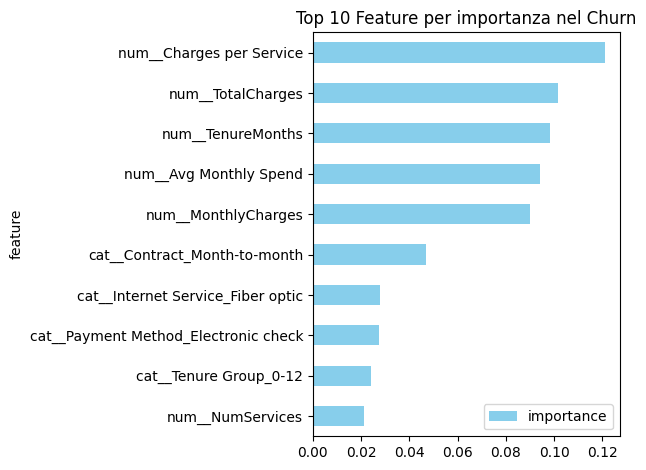

In [9]:
import joblib
import matplotlib.pyplot as plt

# Salvataggio del modello
joblib.dump(pipeline, MODELS_DIR / "churn_pipeline_v1.joblib")

# Estrazione importanza delle feature
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

# Visualizzazione
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(10)

feature_importance_df.plot(kind='barh', x='feature', y='importance', color='skyblue')
plt.title("Top 10 Feature per importanza nel Churn")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()